https://www.nature.com/articles/s41586-021-03569-1

In [3]:
%load_ext autoreload
%autoreload 2

import sys, os

# Add parent directory to Python path
sys.path.append(os.path.abspath(".."))  

In [7]:
from scrna_pipeline.utils import per_sample_export

In [3]:


report = per_sample_export.export_per_sample_h5ads(
    "/Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/GSE171524_RAW_merged.h5ad",
    "/Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_raw",
    sample_key="sample",      # <-- your obs column

    filename_suffix="raw",
)
print(report.n_cells_per_sample)


sample_id
GSM5226574_C51ctr         6099
GSM5226575_C52ctr         4513
GSM5226576_C53ctr         7120
GSM5226577_C54ctr         4382
GSM5226578_C55ctr         5685
GSM5226579_C56ctr         4090
GSM5226580_C57ctr         4789
GSM5226581_L01cov         3060
GSM5226582_L03cov         5060
GSM5226583_L04cov         3630
GSM5226584_L04covaddon    4574
GSM5226585_L05cov         3052
GSM5226586_L06cov         7582
GSM5226587_L07cov         5074
GSM5226588_L08cov         4149
GSM5226589_L09cov         3605
GSM5226590_L10cov         1550
GSM5226591_L11cov         3296
GSM5226592_L12cov         3876
GSM5226593_L13cov         4862
GSM5226594_L15cov         4056
GSM5226595_L16cov         1822
GSM5226596_L17cov         4651
GSM5226597_L18cov         2816
GSM5226598_L19cov         2509
GSM5226599_L21cov         3425
GSM5226600_L22cov         6987
Name: count, dtype: int64


In [6]:
BROAD_MARKERS = {
    "Epithelial": ["EPCAM", "KRT8", "KRT18", "KRT19"],
    "T_cell": ["CD3D", "CD3E", "CD2", "CD8A", "CD4"],
    "B_cell": ["MS4A1", "CD79A", "CD79B"],
    "Myeloid": ["LYZ", "CD68", "CD14", "TYROBP", "LST1", "CSF1R", "FCGR3A"],
    "Endothelial": ["PECAM1", "VWF", "KDR"],
    "Fibroblast": ["COL1A1", "COL1A2", "DCN"],
    "Mast": ["TPSAB1", "TPSB2", "CPA3"],
}

In [ ]:
import scanpy as sc

from scrna_pipeline.core.pipeline import StepContext, run_steps
from scrna_pipeline.pipelines.standard_per_sample import standard_per_sample_pipeline

# 1) Load one raw per-sample h5ad
adata = sc.read_h5ad("/Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_raw/GSM5226595_L16cov.raw.h5ad")



# 2) Build the step list (strict workflow)
steps = standard_per_sample_pipeline(
    batch_key="batch",          # must exist in adata.obs
    marker_dict=BROAD_MARKERS,  # your dict[str, list[str]]
    # optional: override defaults if you want
    # n_top_genes=2000, n_pcs=50, n_neighbors=15, resolution=0.6, ...
)

# 3) Execute steps
ctx = StepContext(verbose=True, strict=True)
adata = run_steps(adata, steps, ctx=ctx)

adata


[steps] 01/03 preprocess_to_pca: start
[QC filter] batch=GSM5226595_L16cov kept 1374/1822 | max_genes=3032, max_counts=6627, max_mito=7.37
[QC filter] removed 448 cells; remaining 1374
Running Scrublet for doublet detection...
Removed 4 predicted doublets
After doublet removal: (1370, 19457)
[steps] 01/03 preprocess_to_pca: done (0.75s)
[steps] 02/03 cluster_and_embed: start
[steps] 02/03 cluster_and_embed: done (1.11s)
[steps] 03/03 broad_annotation: start
[steps] 03/03 broad_annotation: done (0.08s)


/Users/alahi.irfan/Desktop/Local_workspace/scRNA-seq-pipeline/scrna_pipeline/steps/annotation.py:150: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(cluster_key)[score_cols]


AnnData object with n_obs × n_vars = 1370 × 19457
    obs: 'sample', 'file', 'batch', 'sample_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'n_genes', 'doublet_score', 'predicted_doublet', 'leiden', 'broad_Epithelial_score', 'broad_T_cell_score', 'broad_B_cell_score', 'broad_Myeloid_score', 'broad_Endothelial_score', 'broad_Fibroblast_score', 'broad_Mast_score', 'broad_celltype'
    var: 'n_cells', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'scrna_pipeline', 'scrublet', 'log1p', 'hvg', 'pc

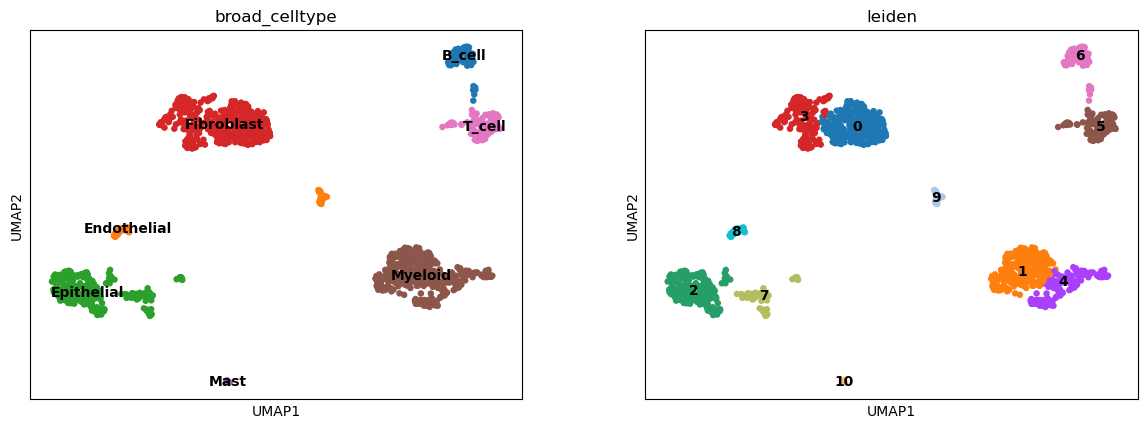

In [14]:
sc.pl.umap(adata, color=["broad_celltype", "leiden"], legend_loc="on data")


# Full Batch

In [12]:
from anndata import AnnData
import scanpy as sc

def show_umap_summary(name: str, adata: AnnData) -> None:
    print(f"\n### Sample: {name}")
    sc.pl.umap(
        adata,
        color=["broad_celltype", "leiden"],
        legend_loc="on data",
        show=True,
    )

In [13]:
from pathlib import Path

from scrna_pipeline.core.batch_runner import (
    BatchRunConfig,
    run_pipeline_on_batch,
    run_pipeline_on_h5ad_folder,
    constant_kwargs_factory,
)
from scrna_pipeline.pipelines.standard_per_sample import standard_per_sample_pipeline

# 1) Config for saving/execution
cfg = BatchRunConfig(
    out_dir=Path("/Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_processed"),
    strip_graph=True,      # remove neighbors graph before saving
    keep_umap=True,        # keep X_umap
    keep_pca=True,         # keep X_pca
    compression="gzip",
    verbose=True,
    strict=True,
)

# 2) Same pipeline kwargs for every sample
kwargs_factory = constant_kwargs_factory({
    "batch_key": "batch",           # must exist in each adata.obs
    "marker_dict": BROAD_MARKERS,   # dict[str, list[str]]
})

# 3) Run for all samples and save <name>.processed.h5ad
saved = run_pipeline_on_batch(
    adatas_dict,  # {"sample1": adata1, "sample2": adata2, ...}
    pipeline=standard_per_sample_pipeline,
    kwargs_factory=kwargs_factory,
    config=cfg,
    on_sample_done=show_umap_summary,

)

# saved is a dict: {sample_name: Path_to_saved_h5ad}
saved


NameError: name 'adatas_dict' is not defined

In [15]:
def debug_uns_scrna_pipeline(sample: str, adata, *args, **kwargs):
    sp = adata.uns.get("scrna_pipeline", None)
    print(f"\n[{sample}] scrna_pipeline type:", type(sp))
    if not isinstance(sp, dict):
        print(f"[{sample}] scrna_pipeline is not a dict; keys in uns:", list(adata.uns.keys())[:30])
        return

    print(f"[{sample}] scrna_pipeline keys:", list(sp.keys()))

    # find any list/tuple that contains non-primitive items
    def is_primitive(x):
        return isinstance(x, (str, int, float, bool, type(None)))

    for k, v in sp.items():
        if isinstance(v, (list, tuple)):
            bad = []
            for i, item in enumerate(v):
                if not is_primitive(item):
                    bad.append((i, type(item), repr(item)[:200]))
            if bad:
                print(f"[{sample}] BAD list at scrna_pipeline['{k}'] len={len(v)}")
                for i, t, r in bad[:10]:
                    print(f"  - idx {i}: {t}  {r}")
        elif isinstance(v, dict):
            # shallow check dict values too
            for kk, vv in v.items():
                if isinstance(vv, (list, tuple)):
                    bad = []
                    for i, item in enumerate(vv):
                        if not is_primitive(item):
                            bad.append((i, type(item), repr(item)[:200]))
                    if bad:
                        print(f"[{sample}] BAD nested list at scrna_pipeline['{k}']['{kk}'] len={len(vv)}")
                        for i, t, r in bad[:10]:
                            print(f"  - idx {i}: {t}  {r}")

    # also check if history list contains only dicts/strings etc.
    hist = sp.get("history", [])
    print(f"[{sample}] history len={len(hist)} types={[type(x) for x in hist]}")


from pathlib import Path

from scrna_pipeline.core.batch_runner import (
    BatchRunConfig,
    run_pipeline_on_batch,
    run_pipeline_on_h5ad_folder,
    constant_kwargs_factory,
)
from scrna_pipeline.pipelines.standard_per_sample import standard_per_sample_pipeline


# 2) Same pipeline kwargs for every sample
kwargs_factory = constant_kwargs_factory({
    "batch_key": "batch",           # must exist in each adata.obs
    "marker_dict": BROAD_MARKERS,   # dict[str, list[str]]
})

cfg = BatchRunConfig(
    out_dir=Path("/Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_some_processed"),
    strip_graph=True,      # remove neighbors graph before saving
    keep_umap=True,        # keep X_umap
    keep_pca=True,         # keep X_pca
    compression="gzip",
    verbose=True,
    strict=True,
)

saved = run_pipeline_on_h5ad_folder(
    "/Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_raw_some",
    pipeline=standard_per_sample_pipeline,
    kwargs_factory=kwargs_factory,
    config=cfg,
    delete_inputs=False,   # deletes raw only after successful save
    on_sample_done=debug_uns_scrna_pipeline,  # or None
)


=== [GSM5226574_C51ctr.raw] loading: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_raw_some/GSM5226574_C51ctr.raw.h5ad ===

=== [GSM5226574_C51ctr.raw] running standard_per_sample_pipeline ===
[steps] 01/03 preprocess_to_pca: start
[QC filter] batch=GSM5226574_C51ctr kept 5102/6099 | max_genes=3266, max_counts=7394, max_mito=3.27
[QC filter] removed 997 cells; remaining 5102
Running Scrublet for doublet detection...
Removed 8 predicted doublets
After doublet removal: (5094, 24660)
[steps] 01/03 preprocess_to_pca: done (11.12s)
[steps] 02/03 cluster_and_embed: start
[steps] 02/03 cluster_and_embed: done (5.47s)
[steps] 03/03 broad_annotation: start


/Users/alahi.irfan/Desktop/Local_workspace/scRNA-seq-pipeline/scrna_pipeline/steps/annotation.py:150: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(cluster_key)[score_cols]


[steps] 03/03 broad_annotation: done (0.22s)

[GSM5226574_C51ctr.raw] scrna_pipeline type: <class 'dict'>
[GSM5226574_C51ctr.raw] scrna_pipeline keys: ['history', 'preprocess_to_pca', 'broad_annotation']
[GSM5226574_C51ctr.raw] history len=0 types=[]
=== [GSM5226574_C51ctr.raw] saved: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_some_processed/GSM5226574_C51ctr.raw.processed.h5ad (50.0 MB) ===

=== [GSM5226575_C52ctr.raw] loading: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_raw_some/GSM5226575_C52ctr.raw.h5ad ===

=== [GSM5226575_C52ctr.raw] running standard_per_sample_pipeline ===
[steps] 01/03 preprocess_to_pca: start
[QC filter] batch=GSM5226575_C52ctr kept 3770/4513 | max_genes=3404, max_counts=9184, max_mito=7.07
[QC filter] removed 743 cells; remaining 3770
Running Scrublet for doublet detection...
Removed 26 predicted doublets
After doublet removal: (3744, 22861)
[steps] 01/03 preprocess_to_pca: done (7.81s)
[steps

/Users/alahi.irfan/Desktop/Local_workspace/scRNA-seq-pipeline/scrna_pipeline/steps/annotation.py:150: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(cluster_key)[score_cols]


=== [GSM5226575_C52ctr.raw] saved: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_some_processed/GSM5226575_C52ctr.raw.processed.h5ad (38.8 MB) ===


In [19]:
from scrna_pipeline.core.pipeline import StepSpec

from scrna_pipeline.steps.preprocessing import BuildEmbeddingPCAStep, PreprocessToPCAStep
from scrna_pipeline.steps.infercnv import InferCNVStep
from scrna_pipeline.steps.clustering import ClusterAndEmbedStep
from pathlib import Path


from scrna_pipeline.core.batch_runner import (
    BatchRunConfig,
    run_pipeline_on_h5ad_folder,
    constant_kwargs_factory,
)

# 2) Same pipeline kwargs for every sample
kwargs_factory = constant_kwargs_factory({
    "batch_key": "batch",           # must exist in each adata.obs

})



def pca_pipe(batch_key):
    steps: list[StepSpec] = [
        StepSpec(
            name="preprocess_to_pca",
            step=PreprocessToPCAStep(
                batch_key=batch_key,
            ),
            mode="required",
            on_error="raise",
        ),
        StepSpec(
            name="cluster_and_embed",
            step=ClusterAndEmbedStep(
            ),
            mode="required",
            on_error="raise",
        ),
        # StepSpec(
        #     name="infercnv",
        #     step=InferCNVStep(
        #             reference_key='broad_cell_type',
        #             reference_categories=["T cell","B cell"],
        #             layer='log1p',
        #             require_log1p=True,
        #         ),
        # )
    

    ]
    return steps

cfg = BatchRunConfig(
    out_dir=Path("/Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_some_processed"),
    strip_graph=True,      # remove neighbors graph before saving
    keep_umap=True,        # keep X_umap
    keep_pca=True,         # keep X_pca
    compression="gzip",
    verbose=True,
    strict=True,
)

saved = run_pipeline_on_h5ad_folder(
    "/Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_raw_some",
    pipeline=pca_pipe,
    kwargs_factory=kwargs_factory,
    config=cfg,
    delete_inputs=False,   # deletes raw only after successful save
    on_sample_done=debug_uns_scrna_pipeline,  # or None
)



=== [GSM5226574_C51ctr.raw] loading: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_raw_some/GSM5226574_C51ctr.raw.h5ad ===

=== [GSM5226574_C51ctr.raw] running pca_pipe ===
[steps] 01/02 preprocess_to_pca: start
[QC filter] batch=GSM5226574_C51ctr kept 5102/6099 | max_genes=3266, max_counts=7394, max_mito=3.27
[QC filter] removed 997 cells; remaining 5102
Running Scrublet for doublet detection...
Removed 8 predicted doublets
After doublet removal: (5094, 24660)
[steps] 01/02 preprocess_to_pca: done (10.30s)
[steps] 02/02 cluster_and_embed: start
[steps] 02/02 cluster_and_embed: done (4.91s)

[GSM5226574_C51ctr.raw] scrna_pipeline type: <class 'dict'>
[GSM5226574_C51ctr.raw] scrna_pipeline keys: ['history', 'preprocess_to_pca']
[GSM5226574_C51ctr.raw] history len=0 types=[]
=== [GSM5226574_C51ctr.raw] saved: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_some_processed/GSM5226574_C51ctr.raw.processed.h5ad (49.7 MB) ===

=== [

# Integration


=== GSM5226586_L06cov.raw.processed.h5ad ===
shape: (5783, 23592)
obs keys: ['sample', 'file', 'batch', 'sample_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'] ...
var keys: ['n_cells', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'] 
layers: ['counts', 'log1p']
obsm: ['X_pca', 'X_umap']
uns has pca: True
has X_pca: True
has umap: True
has neighbors: False
raw: True raw shape: (5783, 23592)


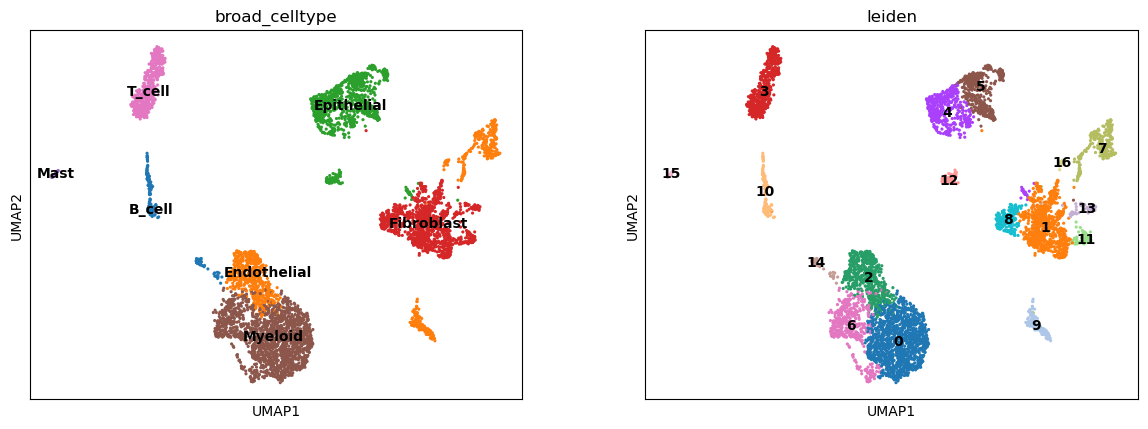


=== GSM5226595_L16cov.raw.processed.h5ad ===
shape: (1370, 19457)
obs keys: ['sample', 'file', 'batch', 'sample_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'] ...
var keys: ['n_cells', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'] 
layers: ['counts', 'log1p']
obsm: ['X_pca', 'X_umap']
uns has pca: True
has X_pca: True
has umap: True
has neighbors: False
raw: True raw shape: (1370, 19457)


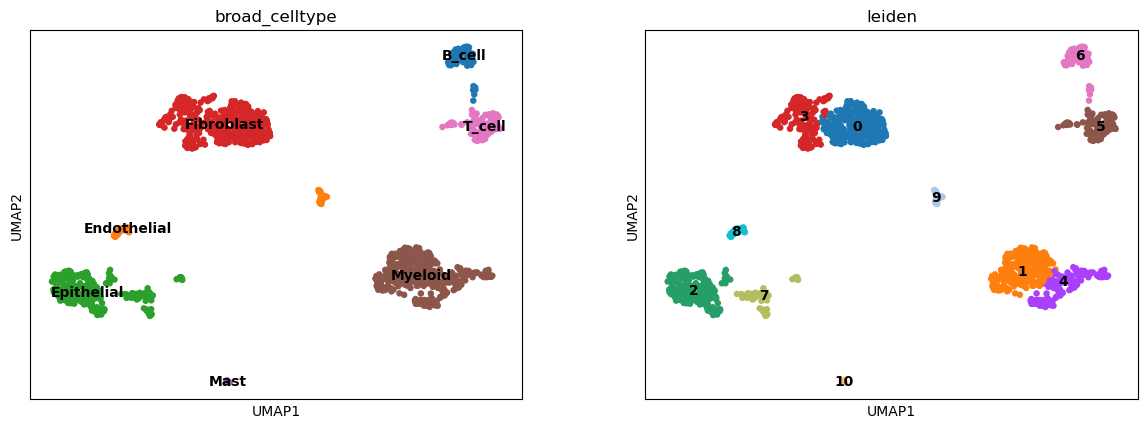

In [47]:
import scanpy as sc
from pathlib import Path

paths = [
    Path("/Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_some_processed/GSM5226586_L06cov.raw.processed.h5ad"),
    Path("/Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_some_processed/GSM5226595_L16cov.raw.processed.h5ad"),
    
]

for p in paths:
    ad = sc.read_h5ad(p)
    print("\n===", p.name, "===")
    print("shape:", ad.shape)
    print("obs keys:", list(ad.obs.columns)[:15], "..." if ad.obs.shape[1] > 15 else "")
    print("var keys:", list(ad.var.columns)[:15], "..." if ad.var.shape[1] > 15 else "")
    print("layers:", list(ad.layers.keys()))
    print("obsm:", list(ad.obsm.keys()))
    print("uns has pca:", "pca" in ad.uns)
    print("has X_pca:", "X_pca" in ad.obsm)
    print("has umap:", "X_umap" in ad.obsm)
    print("has neighbors:", "neighbors" in ad.uns)
    print("raw:", ad.raw is not None, ("raw shape: " + str(ad.raw.shape) if ad.raw is not None else ""))
    sc.pl.umap(
        ad,
        color=["broad_celltype", "leiden"],
        legend_loc="on data",
        show=True,
    )
    


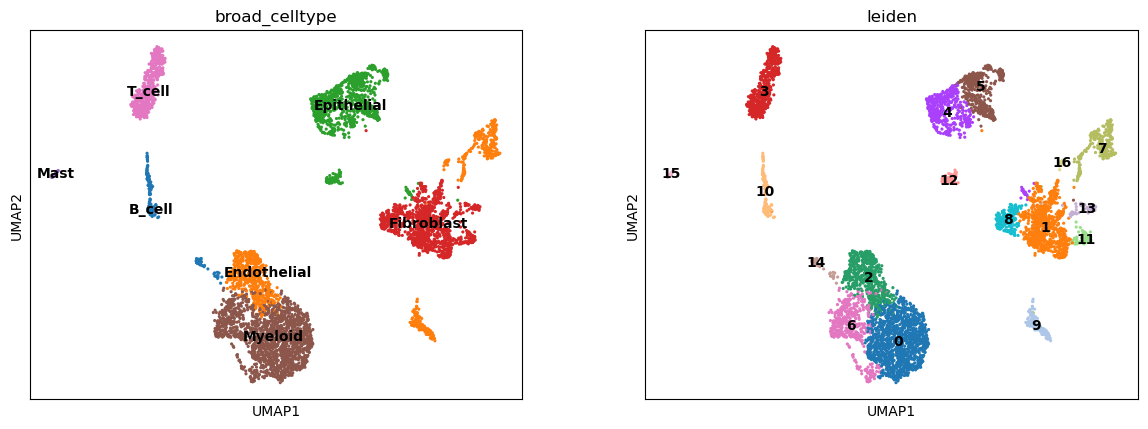

In [48]:
adata = sc.read_h5ad("/Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_some_processed/GSM5226586_L06cov.raw.processed.h5ad")

sc.pl.umap(
        adata,
        color=["broad_celltype", "leiden"],
        legend_loc="on data",
        show=True,
    )

In [49]:
adata_deleted,report = strip_per_sample_artifacts(adata)

print(adata_deleted)

adata_deleted   



AnnData object with n_obs × n_vars = 5783 × 23592
    obs: 'sample', 'file', 'batch', 'sample_id', 'broad_Epithelial_score', 'broad_T_cell_score', 'broad_B_cell_score', 'broad_Myeloid_score', 'broad_Endothelial_score', 'broad_Fibroblast_score', 'broad_Mast_score', 'broad_celltype'
    layers: 'counts', 'log1p'


AnnData object with n_obs × n_vars = 5783 × 23592
    obs: 'sample', 'file', 'batch', 'sample_id', 'broad_Epithelial_score', 'broad_T_cell_score', 'broad_B_cell_score', 'broad_Myeloid_score', 'broad_Endothelial_score', 'broad_Fibroblast_score', 'broad_Mast_score', 'broad_celltype'
    layers: 'counts', 'log1p'

In [7]:
from scrna_pipeline.steps.concat_samples import combine_samples, CombineConfig

combined, reports = combine_samples(
    folder="/Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_processed",
    cfg=CombineConfig(sample_key="sample_id"),
)


In [8]:
print(combined)

AnnData object with n_obs × n_vars = 92587 × 29602
    obs: 'sample', 'file', 'batch', 'sample_id', 'broad_Epithelial_score', 'broad_T_cell_score', 'broad_B_cell_score', 'broad_Myeloid_score', 'broad_Endothelial_score', 'broad_Fibroblast_score', 'broad_Mast_score', 'broad_celltype'
    layers: 'counts', 'log1p'


In [9]:
combined.obs_names.is_unique

True

In [10]:
for k in combined.layers:
    assert combined.layers[k].shape == combined.shape


In [11]:
sc.pp.pca(combined)
sc.pp.neighbors(combined)
sc.tl.umap(combined)

sc.pl.umap(combined, color='sample_id')


NameError: name 'sc' is not defined

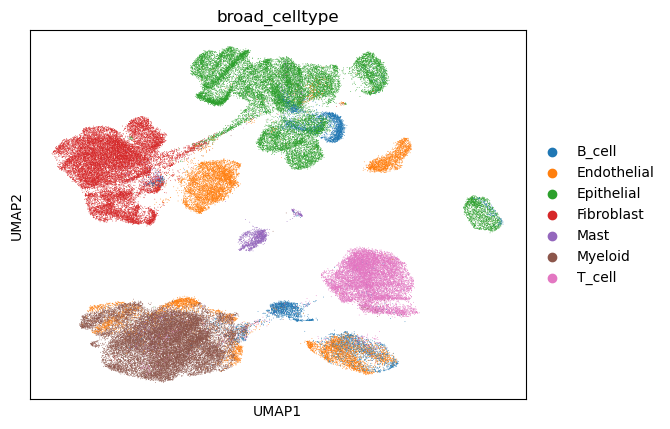

In [ ]:
sc.pl.umap(combined, color='broad_celltype')

In [17]:

import scanpy as sc
from anndata import AnnData

def add_umap_from_rep(
     adata: AnnData,
     *,
     rep_key: str,
     umap_key: str,
     neighbors_key: str,
     n_neighbors: int = 15,
     metric: str = "cosine",
     min_dist: float = 0.5,
     spread: float = 1.0,
     random_state: int = 0,
 ) -> None:
    if rep_key not in adata.obsm:
         raise KeyError(f"{rep_key!r} not found in adata.obsm")
    sc.pp.neighbors(
         adata,
         use_rep=rep_key,
         n_neighbors=n_neighbors,
         metric=metric,
         key_added=neighbors_key,
     )
    sc.tl.umap(
         adata,
         neighbors_key=neighbors_key,
         min_dist=min_dist,
         spread=spread,
         random_state=random_state,
     )
     # Move Scanpy's default 'X_umap' to a custom key
    adata.obsm[umap_key] = adata.obsm["X_umap"].copy()
    del adata.obsm["X_umap"]

from anndata import AnnData

def add_pre_post_umaps(a: AnnData, *, batch_method: str) -> None:
    pre_umap_key = "X_umap_pre_BatchCorrection"
    pre_neighbors_key = "neighbors_pre_BatchCorrection"

    if pre_umap_key not in a.obsm:
        add_umap_from_rep(
            a,
            rep_key="X_pca",
            umap_key=pre_umap_key,
            neighbors_key=pre_neighbors_key,
        )

    if batch_method == "none":
        return

    rep_key = f"X_pca_{batch_method}"
    post_umap_key = f"X_umap_post_BatchCorrection_{batch_method}"
    post_neighbors_key = f"neighbors_post_BatchCorrection_{batch_method}"

    if rep_key not in a.obsm:
        raise RuntimeError(f"batch_method != 'none' but {rep_key} is missing.")

    if post_umap_key not in a.obsm:
        add_umap_from_rep(
            a,
            rep_key=rep_key,
            umap_key=post_umap_key,
            neighbors_key=post_neighbors_key,
        )









from scrna_pipeline.pipelines.integration_from_processed_samples import integration_from_processed_samples_pipeline

from scrna_pipeline.core.integration_runner import run_integration_pipeline, IntegrationRunConfig

adata_int = run_integration_pipeline(
     pipeline=integration_from_processed_samples_pipeline,
     pipeline_kwargs=dict(
         folder="/Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_processed",
        batch_key="sample_id",         batch_method="harmony",
    ),
    postprocess=lambda a: add_pre_post_umaps(a, batch_method="harmony"),
    config=IntegrationRunConfig(out_path=None),
)



[steps] 01/03 combine_samples: start
[steps] 01/03 combine_samples: done (12.85s)
[steps] 02/03 build_embedding_pca: start


2026-01-10 10:42:07,842 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...


[steps] 02/03 build_embedding_pca: done (2.68s)
[steps] 03/03 batch_correction: start
Running Harmony batch correction using batch_key='sample_id'...


2026-01-10 10:42:11,168 - harmonypy - INFO - sklearn.KMeans initialization complete.
2026-01-10 10:42:11,308 - harmonypy - INFO - Iteration 1 of 10
2026-01-10 10:42:24,720 - harmonypy - INFO - Iteration 2 of 10
2026-01-10 10:42:42,110 - harmonypy - INFO - Iteration 3 of 10
2026-01-10 10:42:57,699 - harmonypy - INFO - Iteration 4 of 10
2026-01-10 10:43:12,543 - harmonypy - INFO - Iteration 5 of 10
2026-01-10 10:43:27,527 - harmonypy - INFO - Iteration 6 of 10
2026-01-10 10:43:41,522 - harmonypy - INFO - Iteration 7 of 10
2026-01-10 10:43:53,494 - harmonypy - INFO - Iteration 8 of 10
2026-01-10 10:44:00,009 - harmonypy - INFO - Iteration 9 of 10
2026-01-10 10:44:06,343 - harmonypy - INFO - Iteration 10 of 10
2026-01-10 10:44:12,706 - harmonypy - INFO - Stopped before convergence


[steps] 03/03 batch_correction: done (124.90s)


In [20]:
print(adata_int)

AnnData object with n_obs × n_vars = 92587 × 29602
    obs: 'sample', 'file', 'batch', 'sample_id', 'broad_Epithelial_score', 'broad_T_cell_score', 'broad_B_cell_score', 'broad_Myeloid_score', 'broad_Endothelial_score', 'broad_Fibroblast_score', 'broad_Mast_score', 'broad_celltype'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'scrna_pipeline', 'hvg', 'pca', 'neighbors_pre_BatchCorrection', 'umap', 'neighbors_post_BatchCorrection_harmony'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap_pre_BatchCorrection', 'X_umap_post_BatchCorrection_harmony'
    layers: 'counts', 'log1p'
    obsp: 'neighbors_pre_BatchCorrection_distances', 'neighbors_pre_BatchCorrection_connectivities', 'neighbors_post_BatchCorrection_harmony_distances', 'neighbors_post_BatchCorrection_harmony_connectivities'


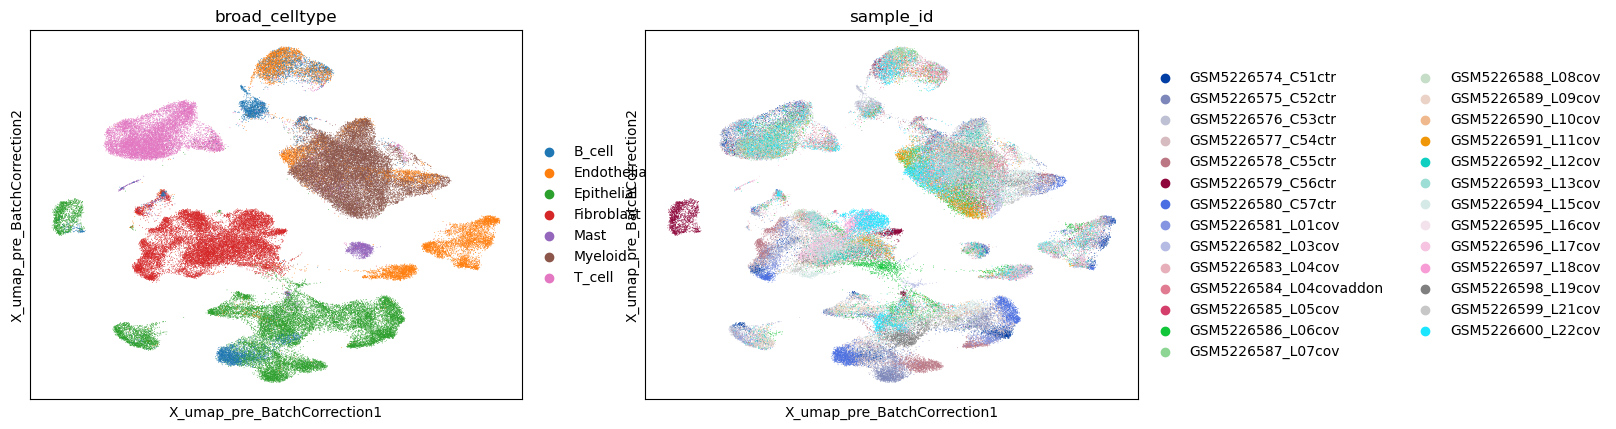

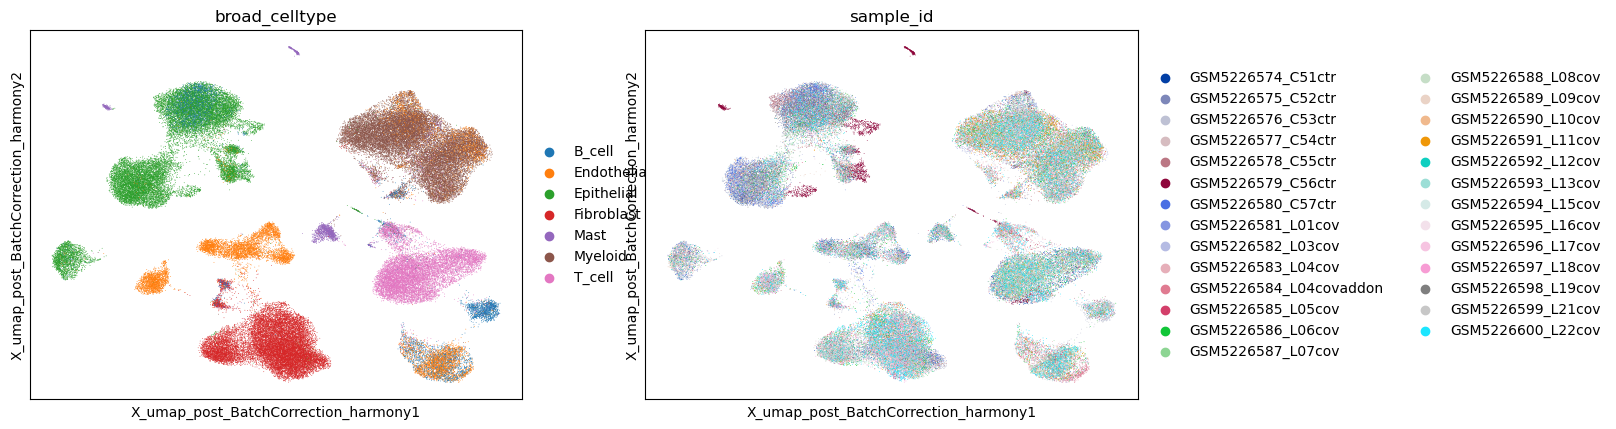

In [23]:
sc.pl.embedding(adata_int, basis="X_umap_pre_BatchCorrection",  color=["broad_celltype", "sample_id"])
sc.pl.embedding(adata_int, basis="X_umap_post_BatchCorrection_harmony", color=["broad_celltype", "sample_id"])

In [24]:
from scrna_pipeline.annotation import score_markers_and_suggest_labels

# ------------------------------------------------------------------
# 1) Define marker dictionary (unchanged)
# ------------------------------------------------------------------
# marker_dict = {
#     # -----------------------
#     # Epithelial subtypes
#     # -----------------------
#     "Epi_Luminal": [
#         "EPCAM", "KRT8", "KRT18", "KRT19",
#         "MUC1",
#     ],
#     "Epi_Basal": [
#         "KRT5", "KRT14", "KRT17", "TP63",
#     ],
#     "Epi_Cycling": [
#         "MKI67", "TOP2A", "BIRC5", "CCNB1", "CDC20",
#     ],

#     # -----------------------
#     # Immune lineages
#     # -----------------------
#     "T_cell": [
#         "CD3D", "CD3E", "CD2", "CD8A", "CD4",
#     ],
#     "B_cell": [
#         "MS4A1", "CD79A", "CD79B",
#     ],
#     "Myeloid": [
#         "LYZ", "S100A8", "S100A9", "LGALS3",
#     ],

#     # -----------------------
#     # Stromal + mast
#     # -----------------------
#     "Endothelial": [
#         "PECAM1", "VWF", "KDR",
#     ],
#     "Fibroblast": [
#         "COL1A1", "COL1A2", "DCN", "LUM",
#     ],
#     "Mast": [
#         "TPSAB1", "TPSB2", "CPA3", "KIT", "HDC", "MS4A2",
#     ],
# }

# marker_dict = {
#     # ----------------------- Immune System -----------------------
#     "CD4+ T cells": [
#         "IL7R", "CCR7", "TCF7", "LTB", "MAL"
#     ],
#     "CD8+ T cells": [
#         "CD8A", "CD8B", "GZMK", "CCL5", "TRAC"
#     ],
#     "Tregs": [
#         "FOXP3", "IL2RA", "CTLA4", "IKZF2", "TNFRSF18"
#     ],
#     "NK cells": [
#         "GNLY", "NKG7", "PRF1", "GZMB", "KLRD1"
#     ],
#     "Cycling T/NK": [
#         "MKI67", "TOP2A", "CENPF", "BIRC5", "ASPM"
#     ],
#     "B cells": [
#         "MS4A1",      # CD20
#         "CD79A",
#         "CD79B",
#         "CD74",
#         "BANK1"
#     ],
#     "Plasma cells": [
#         "JCHAIN",
#         "MZB1",
#         "SDC1",      # CD138
#         "PRDM1",
#         "IGHG1"
#     ],
#     "Monocytes": [
#         "LYZ",
#         "S100A8",
#         "S100A9",
#         "FCN1",
#         "CTSS"
#     ],
#     "Macrophages": [
#         "C1QA",
#         "C1QB",
#         "C1QC",
#         "MRC1",     # CD206
#         "APOE"
#     ],
#     "Dendritic cells": [
#         "ITGAX",     # CD11c (cDC)
#         "CD1C",      # cDC2
#         "CLEC9A",    # cDC1
#         "LILRA4",    # pDC
#         "HLA-DRA"
#     ],
#     "Mast cells": [
#         "KIT",
#         "TPSAB1",
#         "TPSB2",
#         "CPA3",
#         "HDC"
#     ],

#     # ----------------------- Lung Epithelial -----------------------
#     "AT1": [
#         "AGER",
#         "PDPN",
#         "CAV1",
#         "AQP5",
#         "CLDN18"
#     ],
#     "AT2": [
#         "SFTPC",
#         "SFTPB",
#         "SFTPA1",
#         "ABCA3",
#         "SLC34A2"
#     ],
#     "Club epithelial": [
#         "SCGB1A1",
#         "SCGB3A1",
#         "KRT8",
#         "KRT18",
#         "EPCAM"
#     ],
#     "Basal epithelial": [
#         "KRT5",
#         "KRT14",
#         "TP63",
#         "KRT17",
#         "ITGA6"
#     ],

#     # ----------------------- Stromal & Vascular -----------------------
#     "Fibroblasts": [
#         "COL1A1",
#         "COL1A2",
#         "COL3A1",
#         "DCN",
#         "LUM"
#     ],
#     "Smooth muscle / Pericytes": [
#         "ACTA2",
#         "MYH11",
#         "TAGLN",
#         "PDGFRB",
#         "RGS5"
#     ],
#     "Endothelial (vascular)": [
#         "VWF",
#         "PECAM1",    # CD31
#         "CDH5",      # VE-cadherin
#         "KDR",       # VEGFR2
#         "ESAM"
#     ],
#     "Lymphatic endothelial": [
#         "LYVE1",
#         "PROX1",
#         "PDPN",
#         "MMRN1",
#         "CCL21"
#     ],
# }


marker_dict = {
    # ----------------------------- Epithelial -----------------------------
    "Airway epithelial cells": [
        "EPCAM",      # pan-epithelial
        "KRT8", "KRT18",  # luminal epithelial
        "SCGB1A1",        # club/secretory
        "FOXJ1"           # ciliated epithelial program
    ],

    "AT1": [
        "AGER", 
        "PDPN", 
        "CAV1",
        "CLDN18",
        "AQP5"
    ],

    "AT2": [
        "SFTPC",
        "SFTPB",
        "SFTPA1",
        "ABCA3",
        "SLC34A2"
    ],

    "Other epithelial cells": [
        "EPCAM",         # baseline epithelial identity
        "KRT19",         # luminal cytokeratin
        "MUC1",          # surface mucin
        "KRT8", "KRT18"
    ],

    # ----------------------------- Immune (Adaptive) -----------------------------
    "B cells": [
        "MS4A1",        # CD20
        "CD79A",
        "CD79B",
        "CD74",
        "BANK1"
    ],

    "Plasma cells": [
        "JCHAIN",
        "MZB1",
        "SDC1",          # CD138
        "IGHG1",
        "PRDM1"
    ],

    "CD4+ T cells": [
        "IL7R",
        "CCR7",
        "TCF7",
        "LTB",
        "MAL"
    ],

    "CD8+ T cells": [
        "CD8A",
        "CD8B",
        "GZMK",
        "CCL5",
        "TRAC"
    ],

    "Tregs": [
        "FOXP3",
        "IL2RA",
        "CTLA4",
        "IKZF2",
        "TNFRSF18"
    ],

    # ----------------------------- Immune (Innate) -----------------------------
    "NK cells": [
        "GNLY",
        "NKG7",
        "PRF1",
        "GZMB",
        "KLRD1"
    ],

    "Cycling NK/T cells": [
        "MKI67",
        "TOP2A",
        "CENPF",
        "ASPM",
        "BIRC5"
    ],

    "Monocytes": [
        "LYZ",
        "S100A8",
        "S100A9",
        "FCN1",
        "CTSS"
    ],

    "Macrophages": [
        "C1QA",
        "C1QB",
        "C1QC",
        "MRC1",
        "APOE"
    ],

    "Dendritic cells": [
        "ITGAX",         # CD11c
        "CD1C",          # cDC2
        "CLEC9A",        # cDC1
        "LILRA4",        # pDC
        "HLA-DRA"
    ],

    "Mast cells": [
        "KIT",
        "TPSAB1",
        "TPSB2",
        "CPA3",
        "HDC"
    ],

    # ----------------------------- Stromal & Vascular -----------------------------
    "Fibroblasts": [
        "COL1A1",
        "COL1A2",
        "COL3A1",
        "DCN",
        "LUM"
    ],

    "Smooth muscle": [
        "ACTA2",
        "MYH11",
        "TAGLN",
        "RGS5",
        "PDGFRB"
    ],

    "Endothelial cells": [
        "VWF",
        "PECAM1",        # CD31
        "CDH5",          # VE-cadherin
        "KDR",
        "ESAM"
    ],

    # ----------------------------- Nervous system -----------------------------
    "Neuronal cells": [
        "RBFOX3",        # NeuN
        "TUBB3",         # β3-tubulin
        "MAP2",
        "SNAP25",
        "SYT1"
    ],
}





cluster_scores, suggested = score_markers_and_suggest_labels(
    adata_int,
    marker_dict=marker_dict,
    cluster_key="leiden",

)

# ------------------------------------------------------------------
# 4) Pretty display (with fallback if styling fails)
# ------------------------------------------------------------------
try:
    display(
        cluster_scores
        .round(2)
        .style
        .background_gradient(cmap="viridis")
        .set_properties(**{"text-align": "center"})
        .set_table_styles([
            dict(selector="th", props=[("text-align", "center")]),
        ])
    )
except Exception as e:
    # e.g. jinja2 not installed or in non-notebook context
    print("Styled display failed, showing plain table instead:", repr(e))
    display(cluster_scores.round(2))

# If you want, you can also inspect the suggested labels:
suggested


ValueError: Cluster key 'leiden' not found in adata.obs. Did you run clustering?